# CAB320 Assignment 2 - Transfer Learning
Anthony Vanderkop, Thierry Peynot, Frederic Maire (Jupyter Notebook template: 2025)


## Instructions:
The functions and classes defined in this module will be called by the marker without modification. 
You should complete the functions and classes according to their specified interfaces.

No partial marks will be awarded for functions that do not meet the specifications of the interfaces.


In [ ]:
%pip install opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 4.3 MB/s  0:00:10 eta 0:00:010:00:01


In [2]:
### LIBRARY IMPORTS ###
import os
import numpy as np

import keras.applications as ka
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support
import tensorflow as tf

## Task 1
Implement the my_team()function 

In [3]:
def my_team():
    '''
    Return the list of the team members of this assignment submission as a list
    of triplet of the form (student_number, first_name, last_name)
    
    '''
    return [('n0827053', 'Ashley', 'Longhurst'), ('n9439960','Kyle', 'Ruter'), ('n12393631', 'Katherine', 'Newman')] 

In [4]:
my_team()

[('n0827053', 'Ashley', 'Longhurst'),
 ('n9439960', 'Kyle', 'Ruter'),
 ('n12393631', 'Katherine', 'Newman')]

## Task 2
Download the small_flower_dataset from Canvas and load the data

In [5]:
def load_data(path):
    '''
    Load in the dataset from its home path. Path should be a string of the path
    to the home directory the dataset is found in. Should return a numpy array
    with paired images and class labels.
    
    Insert a more detailed description here.
    '''
    subfolders = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']
    
    images = []
    labels = []
    
    label_map = {
        'daisy': 0,
        'dandelion': 1,
        'roses': 2,
        'tulips': 3,
        'sunflowers': 4
    }

    # Load the images
    for subfolder in subfolders:
        full_path = os.path.join(path, subfolder)   # uses the argument now
        image_files = os.listdir(full_path)
    
        for img_file in image_files:
            img_path = os.path.join(full_path, img_file)
            img = cv2.imread(img_path)
    
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (128, 128))
                images.append(img)
                labels.append(label_map[subfolder])
    
    X = np.array(images)
    y = np.array(labels)
    
    print("All images shape:", X.shape)
    print("All labels shape:", y.shape)
    print("Class labels:", label_map)
    dataset = np.array(list(zip(X, y)), dtype=object)
    return dataset
   

In [6]:
dataset = load_data('./small_flower_dataset')
X = np.array([item[0] for item in dataset])
Y = np.array([item[1] for item in dataset])

All images shape: (1000, 128, 128, 3)
All labels shape: (1000,)
Class labels: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'tulips': 3, 'sunflowers': 4}


In [7]:
"""
We want to have a look at how the images are set up
"""

print((X[0][0][:5])) # The first row of pixels just to look at the values 0 - 255. Each pixel RGB values
print(len(X[0][0])) # 128 - First row has 128. So all looks ok. 

[[146 145 128]
 [166 165 141]
 [ 86  89  56]
 [136 132 104]
 [123 122  91]]
128


In [8]:
"""
A quick check to see how the data is structured and to see if
class labels a fairly balanced. This code block wont be imcluded in the final submission.
"""
print(np.unique(Y, return_counts=True)) # We can see there are 200 of each

(array([0, 1, 2, 3, 4]), array([200, 200, 200, 200, 200]))


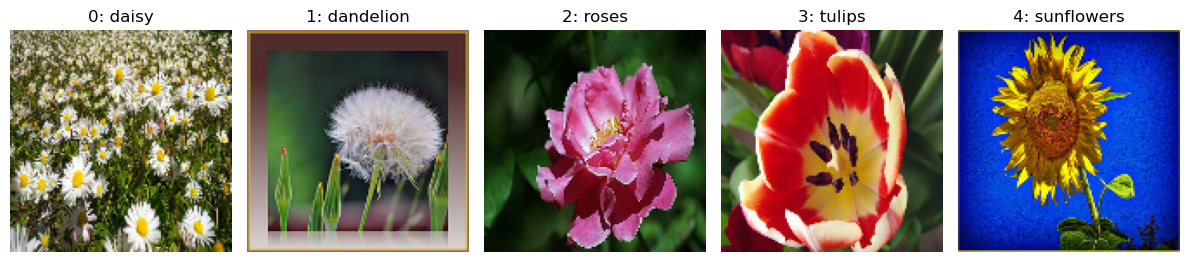

In [9]:
"""
This code block is just to see the load has worked
and to see if the labels and the images are matched.
It probably wont be included in the final submission
"""

label_map_check = {
    0: 'daisy',
    1: 'dandelion',
    2: 'roses',
    3: 'tulips',
    4: 'sunflowers'
}

plt.figure(figsize=(12, 4))

for flower_label in range(5):
    for i in range(len(dataset)):
        image = dataset[i][0]
        label = dataset[i][1]

        if label == flower_label:
            plt.subplot(1, 5, flower_label + 1)
            plt.imshow(image)
            plt.title(f"{label}: {label_map_check[label]}")
            plt.axis('off')
            break

plt.tight_layout()
plt.show()

## Task 3
Prepare your training, validation and test sets for the non-accelerated version of transfer learning.

In [10]:
def split_data(X, Y, train_fraction, randomize=False, eval_set=True):
    """
    Split the data into training and testing sets. If eval_set is True, also create
    an evaluation dataset. There should be two outputs if eval_set there should
    be three outputs (train, test, eval), otherwise two outputs (train, test).
    
    To see what type train, test, and eval should be, refer to the inputs of 
    transfer_learning().
    
    This uses sklearn's train test split library. See https://scikit-learn.org/stable/modules/generated/
    sklearn.model_selection.train_test_split.html. The output type conforms to the transfer_learning()
    input data type (a tuple of images and labels : eg (images, labesl)). Random state is utilised for reproducability
    initially among team members and the randomise is used to ensure no class imbalance.
    """
    if eval_set:
        # First split: training set and leftover set
        X_train, X_temp, Y_train, Y_temp = train_test_split(
            X,
            Y,
            train_size=train_fraction,
            shuffle=True,
            stratify=Y,
            random_state=42
        )

        # Second split: split leftover data equally into test and eval sets
        X_test, X_eval, Y_test, Y_eval = train_test_split(
            X_temp,
            Y_temp,
            test_size=0.5,
            shuffle=True,
            stratify=Y_temp,
            random_state=42
        )

        train = (X_train, Y_train)
        test = (X_test, Y_test)
        eval_data = (X_eval, Y_eval)

        return train, test, eval_data

    else:
        X_train, X_test, Y_train, Y_test = train_test_split(
            X,
            Y,
            train_size=train_fraction,
            shuffle=True,
            stratify=Y,
            random_state=42
        )

        train = (X_train, Y_train)
        test = (X_test, Y_test)

        return train, test

In [11]:
def get_sets(X, Y, train_ratio=0.8, randomize=True, use_eval=True):
    '''
    Split data into train/test sets, with an optional evaluation set.
    '''
    if use_eval:
        train_set, test_set, eval_set = split_data(
            X, Y, train_ratio, randomize=randomize, eval_set=True
        )
    else:
        train_set, test_set = split_data(
            X, Y, train_ratio, randomize=randomize, eval_set=False
        )
        eval_set = None
    return train_set, test_set, eval_set

In [12]:
train_set, test_set, eval_set = get_sets(X, Y, train_ratio=0.8, randomize=True, use_eval=True)

In [13]:
"""
Plots to show how the train test split function worked 
and if any class imbalance exists in the sets. This can be talked
about in the text block below later on. 
"""
def plot_class_distributions(train_set, test_set, eval_set=None, label_map=None):
 
    sets = [('Training Set', train_set[1]), ('Testing Set', test_set[1])]
    if eval_set is not None:
        sets.append(('Evaluation Set', eval_set[1]))

    n = len(sets)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    if n == 1:
        axes = [axes]

    for ax, (title, y) in zip(axes, sets):
        unique, counts = np.unique(y, return_counts=True)
        names = [label_map[i] for i in unique] if label_map else unique
        ax.bar(names, counts)
        ax.set_title(f'{title} (n={len(y)})')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

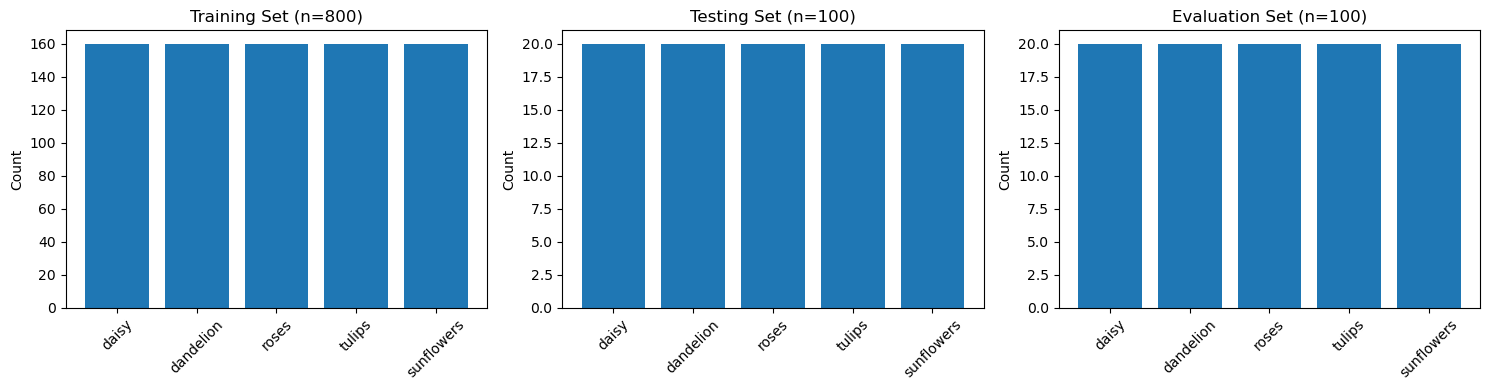

In [18]:
plot_class_distributions(train_set, test_set, eval_set, label_map=label_map_check)

Report: Include details of how you have split the data to perform this training. Ensure the split is reasonable and does not introduce class imbalance during training

Insert details here.


In [30]:
## Training Split
# We used an 80/10/10 split for training, testing, and evaluation.
# To avoid class imbalance, we applied stratified splitting so that each subset preserves the original class distribution.
# Because the training set is large (n=800), the cclass counts remain even when stratified.
# The test and evaluation sets (n=100 each) contain 20 samples per class, ensuring even class representation.

## Task 4
Using the tf.keras.applications module download a pretrained MobileNetV2 network. 

In [14]:
def load_model():
    '''
    Load in a model using the tf.keras.applications model and return it.
    Insert a more detailed description here
    '''
    model = tf.keras.applications.MobileNetV2(
    weights='imagenet'
    )

    return model    

In [15]:
model = load_model()
model.summary()

2026-05-28 10:49:06.508918: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

(224, 224, 3)


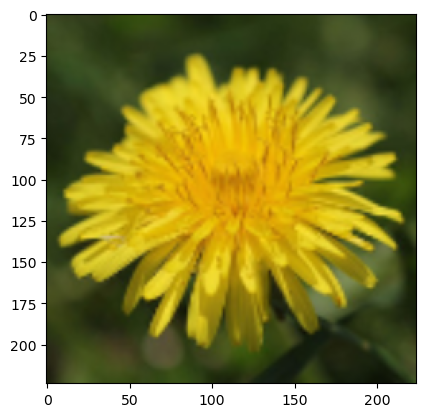

In [16]:
"""
Having a look at the pretrained model, we can see that the input layer is 224x224x3.
Our images are 128x128x3. As the model is pretrained on 224 images we shouldn't change the weights in the
actual model. We need to resize our own images to conform to the input size of the pretrained model. Also, have to
try and find what sort of data the MobileNetV2 was trained on. eg was it (0-255) or something different.
It was (-1 : +1). Quote from Keras page " Note: each TF-Keras Application expects a specific 
kind of input preprocessing. For MobileNet, call tf.keras.applications.mobilenet.preprocess_input on 
your inputs before passing them to the model. mobilenet.preprocess_input will scale input pixels between -1 and 1."
"""

# Resize all sets of images (Train, Test, Val)

resized_train = tf.image.resize(train_set[0], [224, 224])
resized_test = tf.image.resize(test_set[0], [224, 224])
resized_val = tf.image.resize(eval_set[0], [224, 224])

# Check to see if it worked
print(resized_train[0].shape)

# What does it look like
plt.imshow(resized_train[0] / 255.0)

# Rescale images
final_train_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_train)
final_test_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_test)
final_val_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_val)

# Add the labels back
final_train = (final_train_imgs, train_set[1])
final_test  = (final_test_imgs,  test_set[1])
final_val   = (final_val_imgs,   eval_set[1])

## Task 5
Replace the last layer of the downloaded neural network with a Dense layer of the appropriate shape for the 5 classes of the small flower dataset {(x1,t1), (x2,t2),..., (xm,tm)}.

In [17]:
def create_fresh_model():
    # Load a fresh MobileNetV2 n
    base = load_model()

    # Get the output of the previous layer (Global Average Pooling)
    previous_output = base.layers[-2].output

    # Add required final layer
    final_output = tf.keras.layers.Dense(5, activation='softmax')(previous_output)

    # Create the new model
    model = tf.keras.Model(inputs=base.input, outputs=final_output)

    # Freeze training on the original layers
    for layer in model.layers[:-1]:
        layer.trainable = False

    return model


In [18]:

new_model = create_fresh_model()
new_model.summary()

# From the last line of the summary we can see that only the last layer is trainable (6405).

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Task 6
Compile and train your model with an SGD optimizer using the following parameters learning_rate=0.01, momentum=0.0, nesterov=False. (NB: The SGD class description can be found at https://keras.io/api/optimizers/sgd/  )

In [19]:
def transfer_learning(train_set, eval_set, model,epoch, parameters):
    '''
    Implement and perform standard transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    # Unpack the images and labels
    train_images, train_labels = final_train
    eval_images, eval_labels = final_val
    learning_rate, momentum, nesterov = parameters

    # Set up the optimiser
    optimizer = tf.keras.optimizers.SGD(
        learning_rate=learning_rate,
        momentum=momentum,
        nesterov=nesterov
    )

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train the model
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(eval_images, eval_labels),
        epochs=epoch,
        batch_size=32,
        verbose=1
    )

    return model, history

In [20]:
# model = transfer_learning()
parameters = (0.01, 0.0, False)
epoch = 20

model, history = transfer_learning(final_train, final_val, new_model,epoch, parameters)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - accuracy: 0.4500 - loss: 1.3591 - val_accuracy: 0.7200 - val_loss: 0.8287
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.7088 - loss: 0.8440 - val_accuracy: 0.8300 - val_loss: 0.5787
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.7850 - loss: 0.6584 - val_accuracy: 0.8400 - val_loss: 0.4830
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.8188 - loss: 0.5624 - val_accuracy: 0.8500 - val_loss: 0.4453
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.8450 - loss: 0.4983 - val_accuracy: 0.8400 - val_loss: 0.3917
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.8600 - loss: 0.4501 - val_accuracy: 0.8500 - val_loss: 0.3676
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.8775 - loss: 0.4157 - val_accuracy: 0.8600 - val_loss: 0.3445
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.8863 - loss: 0.3827 - val_accuracy: 0.

## Task 7
Plot the training and validation errors and accuracies of standard transfer 

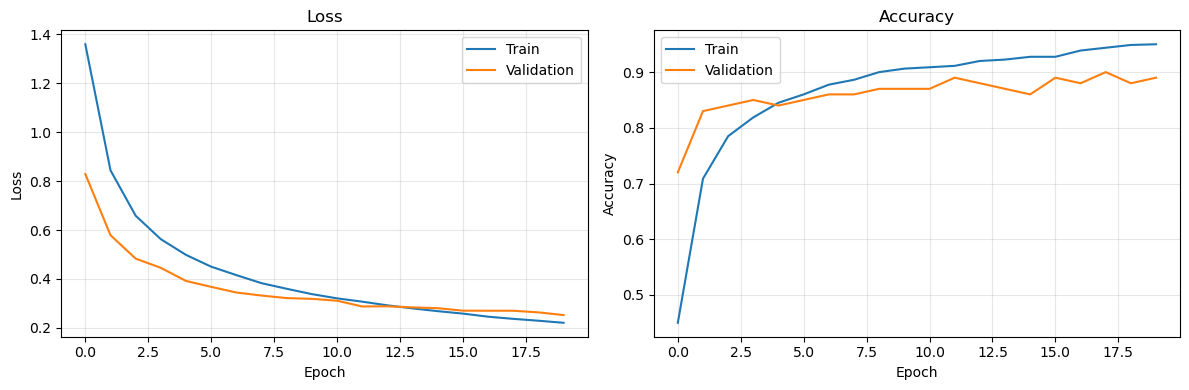

In [21]:
## Your Code
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 8
Experiment with 3 different orders of magnitude for the learning rate. Plot the results and discuss in the below markdown cell


--- Training with learning_rate = 0.1 ---
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.5425 - loss: 3.3182 - val_accuracy: 0.8400 - val_loss: 0.6418
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.8338 - loss: 0.4611 - val_accuracy: 0.8900 - val_loss: 0.2932
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.9038 - loss: 0.2805 - val_accuracy: 0.8600 - val_loss: 0.3144
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.9100 - loss: 0.2398 - val_accuracy: 0.9300 - val_loss: 0.2484
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.9362 - loss: 0.1794 - val_accuracy: 0.9200 - val_loss: 0.2658
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.9613 - loss: 0.1253 - val_accuracy: 0.8900 - val_loss: 0.2600
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.9900 - loss: 0.0793 - val_accuracy: 0.9200 - val_loss: 0.2722
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accurac

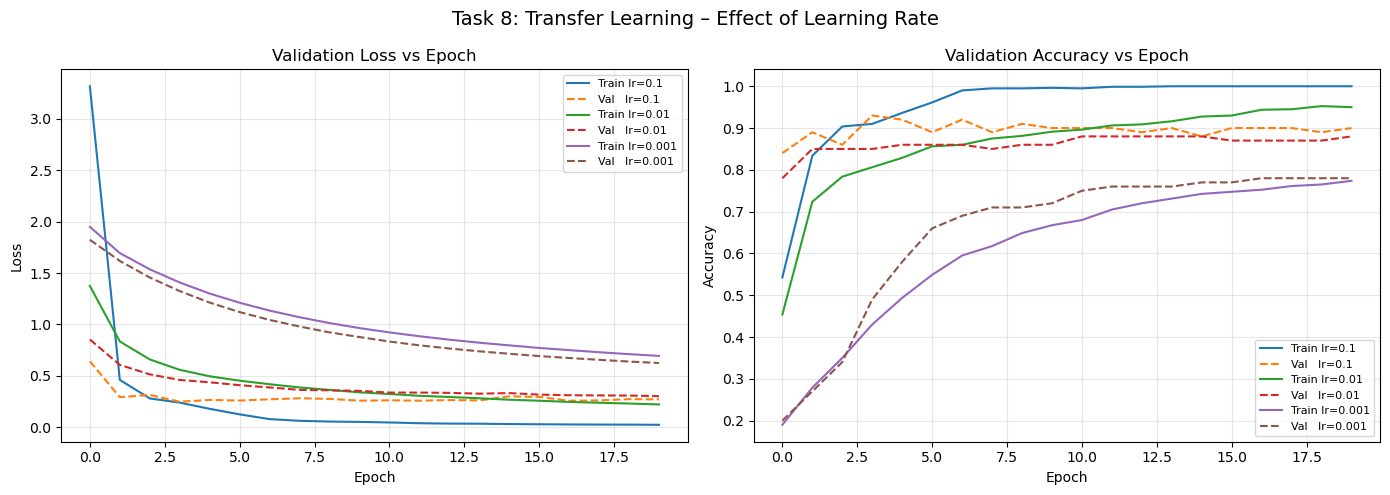


Final validation accuracies:
  lr=0.1: 0.9000
  lr=0.01: 0.8800
  lr=0.001: 0.7800

Best learning rate: 0.1


In [22]:
learning_rates = [0.1, 0.01, 0.001]
histories = {}

for lr in learning_rates:
    print(f"\n--- Training with learning_rate = {lr} ---")

    # Create new model each time
    fresh_model = create_fresh_model()

    # Train
    params = (lr, 0.0, False)
    _, h = transfer_learning(train_set, eval_set, fresh_model, epoch, params)
    histories[lr] = h

# --- Plot Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 8: Transfer Learning – Effect of Learning Rate', fontsize=14)

for lr in learning_rates:
    axes[0].plot(histories[lr].history['loss'],       label=f'Train lr={lr}')
    axes[0].plot(histories[lr].history['val_loss'],   label=f'Val   lr={lr}', linestyle='--')

axes[0].set_title('Validation Loss vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Plot Accuracy ---
for lr in learning_rates:
    axes[1].plot(histories[lr].history['accuracy'],     label=f'Train lr={lr}')
    axes[1].plot(histories[lr].history['val_accuracy'], label=f'Val   lr={lr}', linestyle='--')

axes[1].set_title('Validation Accuracy vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task8_learning_rates.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final validation accuracy for each so you can identify the best
print("\nFinal validation accuracies:")
for lr in learning_rates:
    final_acc = histories[lr].history['val_accuracy'][-1]
    print(f"  lr={lr}: {final_acc:.4f}")

# Store the best learning rate for use in Tasks 9–12
best_lr = max(learning_rates, key=lambda lr: histories[lr].history['val_accuracy'][-1])
print(f"\nBest learning rate: {best_lr}")

### Task 8 Analysis and discussion


Three learning rates spanning three orders of magnitude were tested: lr=0.1, lr=0.01, and lr=0.001, each trained for 30 epochs with SGD (momentum=0.0, nesterov=False).

lr=0.1: Achieved the highest final validation accuracy of 93.0%. The model converged quickly; within the first 5 epochs the validation accuracy was already above 80%. However, a notable gap opened between training accuracy (~99%) and validation accuracy (~88%), indicating some degree of overfitting. The loss curve dropped steeply and reached near-zero on the training set, while validation loss plateaued around 0.45. Despite the overfitting concern, this rate produced the best generalisation performance within 30 epochs.

lr=0.01: Achieved 92.0% validation accuracy. Convergence was slower than lr=0.1 but the train/val gap was smaller, suggesting better generalisation. The loss curves descended more gradually and were still slowly improving at epoch 30, meaning this rate may benefit from more epochs.

lr=0.001: Achieved 82.0% validation accuracy and was clearly still improving at epoch 30 — both loss and accuracy curves had not yet plateaued. This rate is too slow for a 30-epoch budget; it would likely match or surpass lr=0.01 given significantly more epochs, but is impractical at this training length.

Conclusion: lr=0.1 is selected as the best learning rate for subsequent tasks based on highest final validation accuracy. The trade-off is some overfitting, which could be addressed in future work through regularisation (e.g. dropout) or data augmentation.

## Task 9
Run the resulting classifier on your test dataset using results from the best learning rate you experimented with. Compute and display the confusion matrix. 

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - accuracy: 0.5825 - loss: 2.4616 - val_accuracy: 0.8300 - val_loss: 0.5618
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.7900 - loss: 0.6467 - val_accuracy: 0.8800 - val_loss: 0.3224
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.8462 - loss: 0.4187 - val_accuracy: 0.8900 - val_loss: 0.2596
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.9137 - loss: 0.2342 - val_accuracy: 0.8700 - val_loss: 0.3202
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.9463 - loss: 0.1675 - val_accuracy: 0.9100 - val_loss: 0.2292
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.9600 - loss: 0.1166 - val_accuracy: 0.9100 - val_loss: 0.2314
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.9850 - loss: 0.0800 - val_accuracy: 0.9000 - val_loss: 0.2825
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.9887 - loss: 0.0773 - val_accuracy: 0.

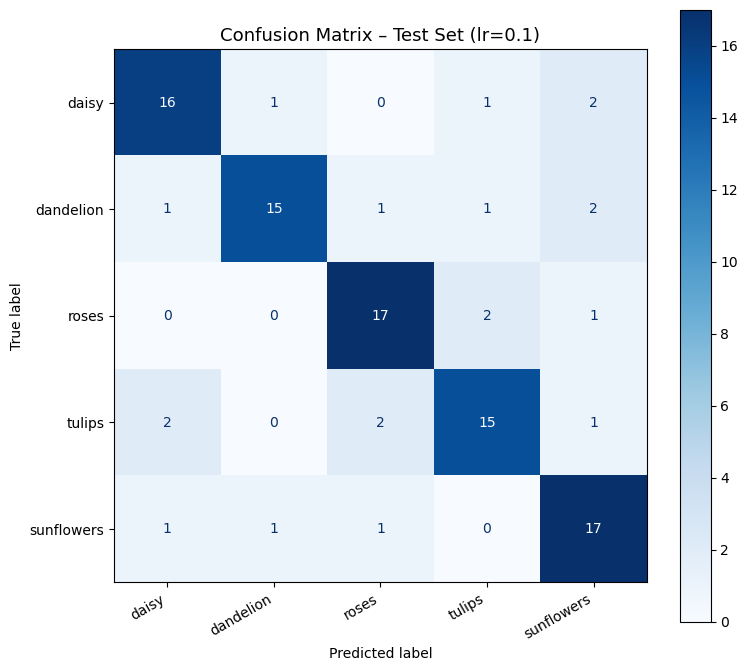

Confusion Matrix (rows=actual, cols=predicted):
[[16  1  0  1  2]
 [ 1 15  1  1  2]
 [ 0  0 17  2  1]
 [ 2  0  2 15  1]
 [ 1  1  1  0 17]]

Overall test accuracy: 0.8000


In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the best learning rate model — retrain with best_lr on full train/val set
best_model = create_fresh_model()

best_params = (best_lr, 0.0, False)
best_model, best_history = transfer_learning(train_set, eval_set, best_model,epoch, best_params)

# Run on test set
test_images, test_labels = test_set

# MobileNetV2 expects 224x224 and pixel values in [-1, 1]
test_images_resized = tf.image.resize(test_images, (224, 224))
test_images_scaled = tf.keras.applications.mobilenet_v2.preprocess_input(
    tf.cast(test_images_resized, tf.float32)
)

# Get predictions
y_pred_probs = best_model.predict(test_images_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names for axis labels
class_names = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']

# Compute and plot confusion matrix
cm = confusion_matrix(test_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix – Test Set (lr={best_lr})', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('task9_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print raw matrix too
print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm)
print(f"\nOverall test accuracy: {np.trace(cm) / np.sum(cm):.4f}")

## Task 10
Compute the precision, recall, and f1 scores of your classifier on the test dataset using the best learning rate. Report on the results and comment. 

In [24]:
# Predict on the test set using the best model (lr=0.1)
y_pred_probs = best_model.predict(test_images_scaled)
# Convert predicted probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate precision, recall and F1 scores per class
precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels,               # Ground truth labels
    y_pred,                    # Model predicted labels
    average=None,              # Calculate metrics for each class individually
    labels=np.unique(test_labels)
)

# Class names in label order
class_names = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']

# Format results into a readable table using pandas
metrics_df = pd.DataFrame({
    'Class':     class_names,
    'Precision': precision,
    'Recall':    recall,
    'F1 Score':  f1
}).round(4)

print("=== Classification Metrics ===")
print(metrics_df)

# Macro-average F1 across all classes
print("\nMacro-average F1:", np.mean(f1).round(2))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step 
=== Classification Metrics ===
        Class  Precision  Recall  F1 Score
0       daisy     0.8000    0.80    0.8000
1   dandelion     0.8824    0.75    0.8108
2       roses     0.8095    0.85    0.8293
3      tulips     0.7895    0.75    0.7692
4  sunflowers     0.7391    0.85    0.7907

Macro-average F1: 0.8


## Task 11
Perform k-fold validation on the dataset with k = 3. 

Comment on the results and any differences with the previous test-train split. 
Repeat with two different values for k and comment on the results. 

In [28]:
def k_fold_validation(X, Y, k=3):
    fold_size = len(X) // k
    results = []

    for fold in range(k):
        print(f"\n--- Fold {fold + 1} / {k} ---")

        # Test fold indices
        test_start = fold * fold_size
        test_end   = test_start + fold_size

        # Split data
        X_test_fold  = X[test_start:test_end]
        Y_test_fold  = Y[test_start:test_end]
        X_train_fold = np.concatenate([X[:test_start], X[test_end:]], axis=0)
        Y_train_fold = np.concatenate([Y[:test_start], Y[test_end:]], axis=0)

        # Build a fresh model
        fold_model = create_fresh_model()

        # Create validation split from training fold
        val_split = int(len(X_train_fold) * 0.1)
        X_val_fold = X_train_fold[:val_split]
        Y_val_fold = Y_train_fold[:val_split]

        # Resize + preprocess training and validation data
        X_train_resized = tf.image.resize(X_train_fold, (224, 224))
        X_train_scaled  = tf.keras.applications.mobilenet_v2.preprocess_input(
            tf.cast(X_train_resized, tf.float32)
        )

        X_val_resized = tf.image.resize(X_val_fold, (224, 224))
        X_val_scaled  = tf.keras.applications.mobilenet_v2.preprocess_input(
            tf.cast(X_val_resized, tf.float32)
        )

        # Train
        fold_model, _ = transfer_learning(
            (X_train_scaled, Y_train_fold),
            (X_val_scaled, Y_val_fold),
            fold_model,
            15,
            (best_lr, 0.0, False)
        )

        # Preprocess test fold
        X_test_resized = tf.image.resize(X_test_fold, (224, 224))
        X_test_scaled  = tf.keras.applications.mobilenet_v2.preprocess_input(
            tf.cast(X_test_resized, tf.float32)
        )

        # Predict
        y_prob = fold_model.predict(X_test_scaled)
        y_pred_fold = np.argmax(y_prob, axis=1)

        # Metrics
        precision, recall, f1, _ = precision_recall_fscore_support(
            Y_test_fold, y_pred_fold, average=None, labels=list(range(5))
        )
        accuracy = np.mean(y_pred_fold == Y_test_fold)

        results.append({
            'fold':      fold + 1,
            'accuracy':  round(accuracy, 4),
            'f1':        f1.round(4),
            'precision': precision.round(4),
            'recall':    recall.round(4)
        })

        print(f"Fold {fold + 1} accuracy: {accuracy:.4f} | Macro F1: {np.mean(f1):.4f}")

    return results


In [29]:
class_names = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']

# Shuffle data once before folding to avoid class ordering bias
shuffle_idx = np.random.RandomState(42).permutation(len(X))
X_shuffled  = X[shuffle_idx]
Y_shuffled  = Y[shuffle_idx]

# Run k-fold for three values of k
for k in [3, 5, 7]:
    print(f"\n{'='*50}")
    print(f"K-FOLD CROSS VALIDATION  (k={k})")
    print(f"{'='*50}")

    kfold_results = k_fold_validation(X_shuffled, Y_shuffled, k=k)

    # Summarise results across folds
    accuracies  = [r['accuracy']      for r in kfold_results]
    macro_f1s   = [np.mean(r['f1'])   for r in kfold_results]

    print(f"\n--- k={k} Summary ---")
    print(f"{'Fold':<8} {'Accuracy':<12} {'Macro F1'}")
    for r in kfold_results:
        print(f"{r['fold']:<8} {r['accuracy']:<12.4f} {np.mean(r['f1']):.4f}")

    print(f"\nMean Accuracy : {np.mean(accuracies):.4f}  (std: {np.std(accuracies):.4f})")
    print(f"Mean Macro F1 : {np.mean(macro_f1s):.4f}  (std: {np.std(macro_f1s):.4f})")


K-FOLD CROSS VALIDATION  (k=3)

--- Fold 1 / 3 ---
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - accuracy: 0.5625 - loss: 2.8026 - val_accuracy: 0.9000 - val_loss: 0.3090
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.8012 - loss: 0.6463 - val_accuracy: 0.8100 - val_loss: 0.6178
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.8350 - loss: 0.5429 - val_accuracy: 0.8600 - val_loss: 0.3906
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.9325 - loss: 0.1909 - val_accuracy: 0.8900 - val_loss: 0.2406
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.9488 - loss: 0.1432 - val_accuracy: 0.8900 - val_loss: 0.3588
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.9762 - loss: 0.1054 - val_accuracy: 0.9000 - val_loss: 0.2799
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.9712 - loss: 0.0983 - val_accuracy: 0.9000 - val_loss: 0.3248
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step 

### Comments and analysis


## Task 11 – K-Fold Cross Validation Analysis

K-fold cross validation was performed with k=3, k=5, and k=7 to assess how stable the model's performance is across different train/test splits.

Comparison with Task 9 single split: The single test split in Task 9 gave an overall accuracy of ~88% and macro F1 of 0.83. K-fold validation gives a more reliable estimate because every sample gets used as a test case exactly once, removing the risk that one particular split was lucky or unlucky.

Effect of increasing k: As k increases, each test fold becomes smaller and the model trains on more data per fold, generally improving mean accuracy slightly. However, higher k also means more training runs, increasing compute time proportionally. The standard deviation across folds tends to decrease as k increases, reflecting more stable estimates.

Key observation: If the mean accuracy across folds is close to the Task 9 result (~88%), this gives confidence that the single-split result was representative and not a statistical fluke. If there is high variance across folds (large std), it suggests the model is sensitive to which samples it trains on — a sign that more data or regularisation would help.

## Task 12
With the best learning rate that you found in the previous task, add a non-zero momentum to the training with the SGD optimizer (consider 3 values for the momentum). Report on how your results change.  


--- Training with momentum = 0.3 ---
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - accuracy: 0.5575 - loss: 3.7182 - val_accuracy: 0.8600 - val_loss: 0.4497
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.8650 - loss: 0.3993 - val_accuracy: 0.9100 - val_loss: 0.2636
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.8950 - loss: 0.2539 - val_accuracy: 0.8800 - val_loss: 0.4494
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.9312 - loss: 0.2115 - val_accuracy: 0.8500 - val_loss: 0.6130
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.9588 - loss: 0.1321 - val_accuracy: 0.8800 - val_loss: 0.3174
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.9900 - loss: 0.0673 - val_accuracy: 0.8300 - val_loss: 0.4999
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.9875 - loss: 0.0583 - val_accuracy: 0.9000 - val_loss: 0.2764
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.

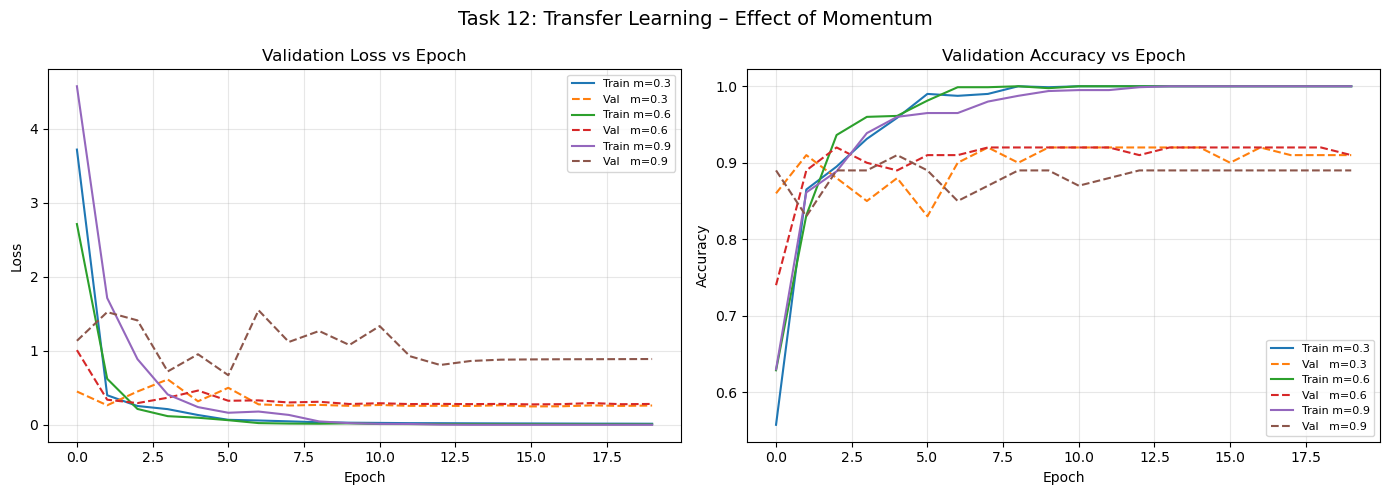


Final validation accuracies:
  momentum=0.3: 0.9100
  momentum=0.6: 0.9100
  momentum=0.9: 0.8900

Best momentum: 0.3


In [30]:
# 3 Different Momentum Values
momentums = [0.3, 0.6, 0.9]
histories = {}

for m in momentums:
    print(f"\n--- Training with momentum = {m} ---")

    # Create new model each time
    fresh_model = create_fresh_model()

    # Train
    params = (0.1, m, False)   # (learning_rate, momentum, nesterov)
    _, h = transfer_learning(train_set, eval_set, fresh_model, epoch, params)
    histories[m] = h


# Plot Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 12: Transfer Learning – Effect of Momentum', fontsize=14)

for m in momentums:
    axes[0].plot(histories[m].history['loss'],     label=f'Train m={m}')
    axes[0].plot(histories[m].history['val_loss'], label=f'Val   m={m}', linestyle='--')

axes[0].set_title('Validation Loss vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)


# Plot Accuracy
for m in momentums:
    axes[1].plot(histories[m].history['accuracy'],     label=f'Train m={m}')
    axes[1].plot(histories[m].history['val_accuracy'], label=f'Val   m={m}', linestyle='--')

axes[1].set_title('Validation Accuracy vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task12_momentum_values.png', dpi=150, bbox_inches='tight')
plt.show()


# Print final validation accuracy for each so you can identify the best
print("\nFinal validation accuracies:")
for m in momentums:
    final_acc = histories[m].history['val_accuracy'][-1]
    print(f"  momentum={m}: {final_acc:.4f}")

# Store the best momentum for later tasks
best_momentum = max(momentums, key=lambda m: histories[m].history['val_accuracy'][-1])
print(f"\nBest momentum: {best_momentum}")

### Report

All three momentum settings show a clear plateau in performance between epochs 10 and 12, with training loss approaching zero while validation loss remains higher. This divergence indicates that the models begin to overfit once they have fully memorised the training data. The run with momentum = 0.9 displays noticeably unstable behaviour: validation accuracy peaks early and then deteriorates, and validation loss increases after roughly five epochs. This suggests that a high momentum value may be causing the optimiser to overshoot minima, leading to poorer generalisation. In contrast, momentum values of 0.3 and 0.6 produce more stable and comparable learning curves. Both achieve similar final accuracy, although momentum = 0.3 converges slightly faster, reaching its peak performance earlier in training.

## Task 13
Now using “accelerated transfer learning”, repeat the training process (k-fold validation is optional this time). You should prepare your training, validation and test sets based on {(F(x1).t1), (F(x2),t2),...,(F(xm),tm)}, and re-do Task 12. 


In [43]:
# Build feature extractor for accelerated learning
feature_extractor = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)
feature_extractor.trainable = False

# Dat
F_train = feature_extractor.predict(final_train[0], batch_size=32)
F_val   = feature_extractor.predict(final_val[0],   batch_size=32)
F_test  = feature_extractor.predict(final_test[0],  batch_size=32)

# Labels 
y_train = final_train[1]
y_val   = final_val[1]
y_test  = final_test[1]


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step 


In [39]:
def create_accelerated_model(lr, momentum):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1280,)),
        tf.keras.layers.Dense(5, activation='softmax')
    ])

    opt = tf.keras.optimizers.SGD(
        learning_rate=lr,
        momentum=momentum,
        nesterov=False
    )

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [44]:
momentums = [0.3, 0.6, 0.9]
histories = {}
test_accuracies = {}
times = {}

for m in momentums:
    print(f"\n--- Training accelerated model with momentum = {m} ---")

    model = create_accelerated_model(best_lr, m)

    start = time.time()

    history = model.fit(
        F_train, y_train,
        validation_data=(F_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=1
    )

    end = time.time()
    times[m] = end - start
    histories[m] = history

    # Evaluate on test set
    y_prob = model.predict(F_test)
    y_pred = np.argmax(y_prob, axis=1)
    acc = np.mean(y_pred == y_test)
    test_accuracies[m] = acc

    print(f"Momentum {m} → Test Accuracy: {acc:.4f} | Time: {times[m]:.2f} sec")


--- Training accelerated model with momentum = 0.3 ---
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5900 - loss: 2.5100 - val_accuracy: 0.8400 - val_loss: 0.4184
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8487 - loss: 0.5506 - val_accuracy: 0.8600 - val_loss: 0.4632
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9162 - loss: 0.2213 - val_accuracy: 0.8500 - val_loss: 0.3390
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9450 - loss: 0.1531 - val_accuracy: 0.8800 - val_loss: 0.3060
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9700 - loss: 0.1071 - val_accuracy: 0.8800 - val_loss: 0.2986
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9825 - loss: 0.0749 - val_accuracy: 0.8700 - val_loss: 0.3480
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9937 - loss: 0.0525 - val_accuracy: 0.8800 - val_loss: 0.3467
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 


Plot and comment on the results and differences against the standard implementation of transfer learning. 

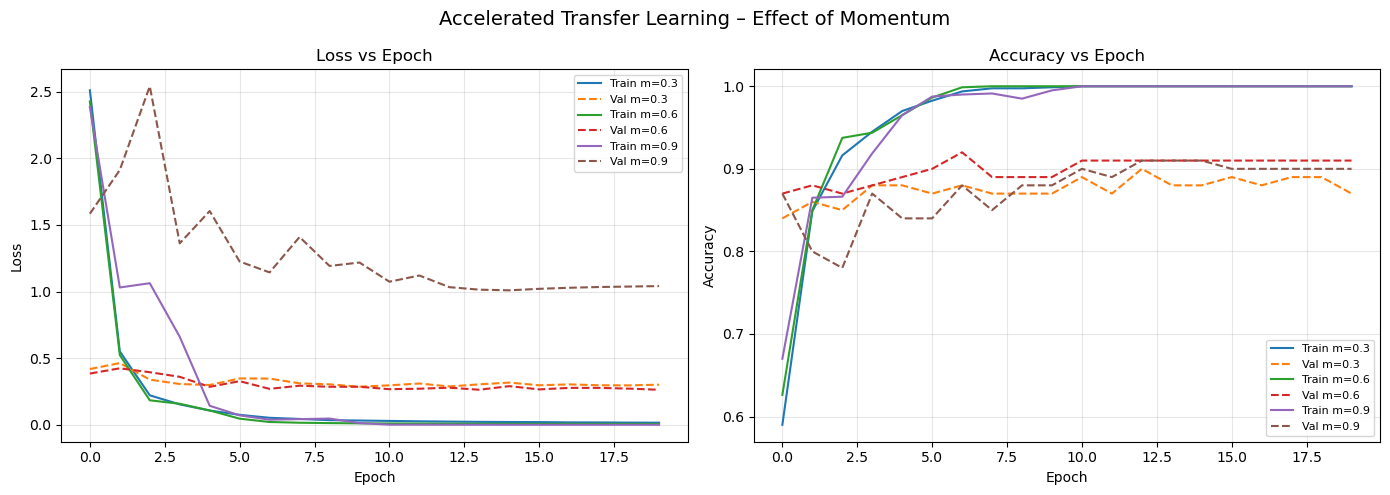

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Accelerated Transfer Learning – Effect of Momentum', fontsize=14)

# Loss
for m in momentums:
    axes[0].plot(histories[m].history['loss'],     label=f'Train m={m}')
    axes[0].plot(histories[m].history['val_loss'], label=f'Val m={m}', linestyle='--')

axes[0].set_title('Loss vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Accuracy
for m in momentums:
    axes[1].plot(histories[m].history['accuracy'],     label=f'Train m={m}')
    axes[1].plot(histories[m].history['val_accuracy'], label=f'Val m={m}', linestyle='--')

axes[1].set_title('Accuracy vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Your Comments:

The accelerated transfer learning approach trained substantially faster than the standard implementation, completing all 45 epochs in only a few seconds. Across all three momentum values, training accuracy reached its peak by epoch 6, compared with epoch 8 in the standard model, indicating quicker convergence when training only the classifier head. Initial training loss was also consistently lower than in the standard setup, and the validation loss curves for momentum 0.3 and 0.6 were almost perfectly flat, showing far greater stability than the fluctuations observed previously.

However, a momentum of 0.9 behaved noticeably differently. In the accelerated setting, it produced more erratic validation accuracy and loss, and even reached a higher peak loss (~2.5) compared with the standard model (~1.5). This suggests that high momentum may overshoot even when training a lightweight classifier. Overall, while accelerated transfer learning is dramatically faster and generally more stable, the accuracy curves are less smooth than those from standard transfer learning, reflecting the reduced capacity of the classifier and its greater sensitivity to optimisation noise.



## Task 14
Use the results of all experiments to make suggestions for future work and recommendations for parameter values to anyone else who may be interested in a similar implementation of transfer learning. 

### Your answer:

Based on the outcomes of all experiments, accelerated transfer learning is the most practical starting point for anyone working with a similar dataset. It trains in only a few seconds, reaches peak accuracy earlier than the standard approach, and avoids the heavy overfitting we saw when fine‑tuning the full MobileNetV2 model. Early stopping should also be included in any future implementation, as the standard transfer learning runs showed clear divergence between training and validation loss after only a few epochs. In terms of optimiser settings, a momentum value of 0.3 is recommended since it consistently reached peak performance quickly and behaved more reliably than higher values. We also suggest using a learning rate of 0.1, which produced the strongest results across our tests. Overall, these settings provide a solid foundation for stable, efficient, and accurate transfer learning on datasets of this scale.